# 🚗 Chicago Traffic Crash Cause Prediction & Interpretability Project

---

## 📌 Introduction: Real-World Problem
Traffic accidents are a major public safety concern in urban areas such as Chicago. Each crash is influenced by multiple interacting factors, including road conditions, weather, vehicle characteristics, and human behavior. Understanding these factors is essential for reducing accidents and improving road safety outcomes.

---

## 🎯 Problem Statement
The objective of this project is to develop a machine learning model that predicts the **primary contributory cause of a traffic crash** using crash, vehicle, and people-related data.

This is a multi-class classification problem where the model learns patterns associated with different crash causes.

---

## 👥 Stakeholders and Use Cases
This project is relevant to several real-world stakeholders:

- **City of Chicago Department of Transportation**: Can use insights to improve road infrastructure and identify high-risk locations.
- **Traffic Safety Authorities**: Can design targeted safety campaigns and interventions based on risk factors.
- **Insurance Companies**: Can better assess risk and improve pricing models.
- **Urban Planners**: Can use findings to improve road design and traffic flow.
- **Emergency Response Teams**: Can optimize resource allocation and preparedness based on risk patterns.

---

## ❓ Why This Matters
Understanding crash patterns helps answer important questions such as:

- Which conditions most frequently lead to accidents?
- Can crash causes be predicted using environmental or behavioral factors?
- How can data be used to reduce future accidents and improve road safety?

---

## 🏁 Conclusion: Project Value
This project is a proof of concept demonstrating how machine learning can be used to identify patterns in traffic crash data. The insights generated can support data-driven decision-making aimed at improving road safety, reducing accident rates, and enhancing public safety planning.

# 📊 2. Data Understanding

## 📁 Data Sources

This project uses three datasets from the City of Chicago:

### 🚗 Crashes Dataset
Contains information about traffic crashes including:
- Weather conditions
- Lighting conditions
- Road surface conditions
- Primary contributory cause (target variable)

### 🚘 Vehicles Dataset
Contains vehicle-level information such as:
- Vehicles involved in each crash
- Vehicle identifiers used to compute total vehicles per crash

### 👤 People Dataset
Contains information about individuals involved in crashes such as:
- Driver age
- Injury classification
- Crash participation details

These datasets are linked using the `crash_record_id` field.

In [133]:
# loading datsets

import pandas as pd

# Load datasets
crashes = pd.read_csv("data/crashes.csv")
vehicles = pd.read_csv("data/vehicles.csv")
people = pd.read_csv("data/people.csv")

# Preview each dataset
print("CRASHES DATA")
display(crashes.head())

print("VEHICLES DATA")
display(vehicles.head())

print("PEOPLE DATA")
display(people.head())

c:\Users\admin\anaconda3\envs\learn-env\lib\site-packages\IPython\core\interactiveshell.py:3145: DtypeWarning: Columns (18,39,40,41,43,47,48,49,52,54,57,58,60) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


CRASHES DATA


,crash_record_id,crash_date_est_i,crash_date,posted_speed_limit,traffic_control_device,device_condition,weather_condition,lighting_condition,first_crash_type,trafficway_type,...,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,injuries_unknown,crash_hour,crash_day_of_week,idot_control_no,latitude,longitude,location
0,000013b0123279411e0ec856dae95ab9f0851764350b7f...,NaN,2020-11-16T13:50:00.000,35,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,PARKED MOTOR VEHICLE,PARKING LOT,...,0.0,0.0,1.0,0.0,13,2,X002073980,41.844584,-87.695360,POINT (-87.695359843215 41.844584300311)
1,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,NaN,2016-04-16T05:49:00.000,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,DAWN,SIDESWIPE SAME DIRECTION,OTHER,...,0.0,0.0,2.0,0.0,5,7,X000473010,41.844734,-87.695363,POINT (-87.695363066709 41.844733938666)
2,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b4...,Y,2019-12-22T02:11:00.000,30,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",FIXED OBJECT,NOT DIVIDED,...,0.0,0.0,1.0,0.0,2,1,X001788722,41.691319,-87.540255,POINT (-87.540255297708 41.691318518437)
3,00005696946846c8b8a1d378dba4e2a5ed84a9b2876fe0...,NaN,2024-02-02T09:48:00.000,30,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,FIXED OBJECT,OTHER,...,0.0,0.0,1.0,0.0,9,6,X003310805,41.811261,-87.606750,POINT (-87.606749972034 41.811261436387)
4,000070ed7a6357c3298f5edc6fb7d5ce925a10f46660f3...,NaN,2016-10-24T02:42:00.000,35,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",SIDESWIPE SAME DIRECTION,DIVIDED - W/MEDIAN (NOT RAISED),...,0.0,0.0,2.0,0.0,2,2,X000625684,41.873272,-87.695937,POINT (-87.69593723519 41.873272095065)


VEHICLES DATA


,crash_unit_id,crash_record_id,crash_date,unit_no,unit_type,num_passengers,vehicle_id,cmrc_veh_i,make,model,...,trailer1_length,trailer2_length,total_vehicle_length,axle_cnt,vehicle_config,cargo_body_type,load_type,hazmat_out_of_service_i,mcs_out_of_service_i,hazmat_class
0,995163,000013b0123279411e0ec856dae95ab9f0851764350b7f...,2020-11-16T13:50:00.000,1,DRIVER,NaN,943049.0,NaN,HYUNDAI,SONATA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,995164,000013b0123279411e0ec856dae95ab9f0851764350b7f...,2020-11-16T13:50:00.000,2,PARKED,NaN,943051.0,NaN,CHEVROLET,TRAVERSE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,40893,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,2016-04-16T05:49:00.000,1,DRIVER,NaN,39524.0,NaN,LINCOLN-CONTINENTAL,MKZ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,40894,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,2016-04-16T05:49:00.000,2,DRIVER,NaN,39526.0,NaN,HYUNDAI,SONATA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,807770,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b4...,2019-12-22T02:11:00.000,1,DRIVER,NaN,767006.0,NaN,LINCOLN-CONTINENTAL,TOWNCAR,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


PEOPLE DATA


,person_id,person_type,crash_record_id,vehicle_id,crash_date,seat_no,city,state,zipcode,sex,...,ems_run_no,driver_action,driver_vision,physical_condition,pedpedal_action,pedpedal_visibility,pedpedal_location,bac_result,bac_result_value,cell_phone_use
0,O995163,DRIVER,000013b0123279411e0ec856dae95ab9f0851764350b7f...,943049.0,2020-11-16T13:50:00.000,NaN,CHICAGO,IL,60642,F,...,NaN,IMPROPER PARKING,UNKNOWN,NORMAL,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
1,O40893,DRIVER,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,39524.0,2016-04-16T05:49:00.000,NaN,NaN,NaN,NaN,X,...,NaN,IMPROPER LANE CHANGE,UNKNOWN,UNKNOWN,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
2,O40894,DRIVER,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,39526.0,2016-04-16T05:49:00.000,NaN,CHICAGO,IL,60639,F,...,NaN,NONE,NOT OBSCURED,NORMAL,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
3,O807770,DRIVER,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b4...,767006.0,2019-12-22T02:11:00.000,NaN,NaN,NaN,NaN,X,...,NaN,UNKNOWN,UNKNOWN,UNKNOWN,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN
4,O1752154,DRIVER,00005696946846c8b8a1d378dba4e2a5ed84a9b2876fe0...,1668221.0,2024-02-02T09:48:00.000,NaN,CHICAGO,IL,60633,M,...,NaN,EMERGENCY VEHICLE ON CALL,NOT OBSCURED,NORMAL,NaN,NaN,NaN,TEST NOT OFFERED,NaN,NaN


## 📏 Dataset Size

We check the size of each dataset to understand how much data we are working with.

In [134]:
print("Crashes shape:", crashes.shape)
print("Vehicles shape:", vehicles.shape)
print("People shape:", people.shape)

Crashes shape: (100000, 49)
Vehicles shape: (200000, 71)
People shape: (200000, 29)


## 🔍 Data Properties

We inspect column types and missing values to understand data quality and structure.

In [135]:
#check the collumns in each dataset
print(crashes.columns)


Index(['crash_record_id', 'crash_date_est_i', 'crash_date',
       'posted_speed_limit', 'traffic_control_device', 'device_condition',
       'weather_condition', 'lighting_condition', 'first_crash_type',
       'trafficway_type', 'lane_cnt', 'alignment', 'roadway_surface_cond',
       'road_defect', 'report_type', 'crash_type', 'intersection_related_i',
       'private_property_i', 'hit_and_run_i', 'damage', 'date_police_notified',
       'prim_contributory_cause', 'sec_contributory_cause', 'street_no',
       'street_direction', 'street_name', 'beat_of_occurrence',
       'photos_taken_i', 'statements_taken_i', 'dooring_i', 'work_zone_i',
       'work_zone_type', 'workers_present_i', 'num_units', 'crash_month',
       'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication',
       'injuries_unknown', 'crash_hour', 'crash_day_of_week',
       'idot_contro

In [136]:
# columns in vehicles dataset
print(vehicles.columns)


Index(['crash_unit_id', 'crash_record_id', 'crash_date', 'unit_no',
       'unit_type', 'num_passengers', 'vehicle_id', 'cmrc_veh_i', 'make',
       'model', 'lic_plate_state', 'vehicle_year', 'vehicle_defect',
       'vehicle_type', 'vehicle_use', 'travel_direction', 'maneuver',
       'towed_i', 'fire_i', 'occupant_cnt', 'exceed_speed_limit_i', 'towed_by',
       'towed_to', 'area_00_i', 'area_01_i', 'area_02_i', 'area_03_i',
       'area_04_i', 'area_05_i', 'area_06_i', 'area_07_i', 'area_08_i',
       'area_09_i', 'area_10_i', 'area_11_i', 'area_12_i', 'area_99_i',
       'first_contact_point', 'cmv_id', 'usdot_no', 'ccmc_no', 'ilcc_no',
       'commercial_src', 'gvwr', 'carrier_name', 'carrier_state',
       'carrier_city', 'hazmat_placards_i', 'hazmat_name', 'un_no',
       'hazmat_present_i', 'hazmat_report_i', 'hazmat_report_no',
       'mcs_report_i', 'mcs_report_no', 'hazmat_vio_cause_crash_i',
       'mcs_vio_cause_crash_i', 'idot_permit_no', 'wide_load_i',
       'trailer1_

In [137]:
# column in people dataset
print(people.columns)

Index(['person_id', 'person_type', 'crash_record_id', 'vehicle_id',
       'crash_date', 'seat_no', 'city', 'state', 'zipcode', 'sex', 'age',
       'drivers_license_state', 'drivers_license_class', 'safety_equipment',
       'airbag_deployed', 'ejection', 'injury_classification', 'hospital',
       'ems_agency', 'ems_run_no', 'driver_action', 'driver_vision',
       'physical_condition', 'pedpedal_action', 'pedpedal_visibility',
       'pedpedal_location', 'bac_result', 'bac_result_value',
       'cell_phone_use'],
      dtype='object')


In [138]:
# check for missing values and info for all datsets

print("CRASHES INFO")
display(crashes.info())

print("\nMissing values (Crashes):")
display(crashes.isna().sum())


print("\nVEHICLES INFO")
display(vehicles.info())

print("\nMissing values (Vehicles):")
display(vehicles.isna().sum())


print("\nPEOPLE INFO")
display(people.info())

print("\nMissing values (People):")
display(people.isna().sum())

CRASHES INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 49 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_record_id                100000 non-null  object 
 1   crash_date_est_i               7253 non-null    object 
 2   crash_date                     100000 non-null  object 
 3   posted_speed_limit             100000 non-null  int64  
 4   traffic_control_device         100000 non-null  object 
 5   device_condition               100000 non-null  object 
 6   weather_condition              100000 non-null  object 
 7   lighting_condition             100000 non-null  object 
 8   first_crash_type               100000 non-null  object 
 9   trafficway_type                100000 non-null  object 
 10  lane_cnt                       18696 non-null   float64
 11  alignment                      100000 non-null  object 
 12  roadway_surface_co

None


Missing values (Crashes):


crash_record_id                      0
crash_date_est_i                 92747
crash_date                           0
posted_speed_limit                   0
traffic_control_device               0
device_condition                     0
weather_condition                    0
lighting_condition                   0
first_crash_type                     0
trafficway_type                      0
lane_cnt                         81304
alignment                            0
roadway_surface_cond                 0
road_defect                          0
report_type                       3443
crash_type                           0
intersection_related_i           76986
private_property_i               95457
hit_and_run_i                    68503
damage                               0
date_police_notified                 0
prim_contributory_cause              0
sec_contributory_cause               0
street_no                            0
street_direction                     1
street_name              


VEHICLES INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 71 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   crash_unit_id             200000 non-null  int64  
 1   crash_record_id           200000 non-null  object 
 2   crash_date                200000 non-null  object 
 3   unit_no                   200000 non-null  int64  
 4   unit_type                 199739 non-null  object 
 5   num_passengers            29387 non-null   float64
 6   vehicle_id                195082 non-null  float64
 7   cmrc_veh_i                3748 non-null    object 
 8   make                      195082 non-null  object 
 9   model                     195070 non-null  object 
 10  lic_plate_state           177367 non-null  object 
 11  vehicle_year              164574 non-null  float64
 12  vehicle_defect            195082 non-null  object 
 13  vehicle_type              195

...

crash_unit_id                   0
crash_record_id                 0
crash_date                      0
unit_no                         0
unit_type                     261
                            ...  
cargo_body_type            198453
load_type                  198522
hazmat_out_of_service_i    198648
mcs_out_of_service_i       198618
hazmat_class               199861
Length: 71, dtype: int64


PEOPLE INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 29 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   person_id              200000 non-null  object 
 1   person_type            200000 non-null  object 
 2   crash_record_id        200000 non-null  object 
 3   vehicle_id             195653 non-null  float64
 4   crash_date             200000 non-null  object 
 5   seat_no                39862 non-null   float64
 6   city                   145957 non-null  object 
 7   state                  148082 non-null  object 
 8   zipcode                134906 non-null  object 
 9   sex                    196806 non-null  object 
 10  age                    142131 non-null  float64
 11  drivers_license_state  117663 non-null  object 
 12  drivers_license_class  97172 non-null   object 
 13  safety_equipment       199419 non-null  object 
 14  airbag_deployed        

None


Missing values (People):


person_id                     0
person_type                   0
crash_record_id               0
vehicle_id                 4347
crash_date                    0
seat_no                  160138
city                      54043
state                     51918
zipcode                   65094
sex                        3194
age                       57869
drivers_license_state     82337
drivers_license_class    102828
safety_equipment            581
airbag_deployed            4192
ejection                   2674
injury_classification        75
hospital                 168686
ems_agency               180768
ems_run_no               196733
driver_action             40216
driver_vision             40310
physical_condition        40129
pedpedal_action          195840
pedpedal_visibility      195845
pedpedal_location        195838
bac_result                40140
bac_result_value         199790
cell_phone_use           199904
dtype: int64

## 🎯 Feature Relevance

The features in these datasets are relevant to predicting crash causes:

### Environmental Factors
- Weather conditions
- Lighting conditions
- Road surface conditions

### Vehicle Factors
- Number of vehicles involved (derived feature)

### Human Factors
- Driver age
- Injury classification

These features are useful because they represent real-world factors that influence crash outcomes.

## 📊 Descriptive Statistics

We use summary statistics to understand distributions and detect missing or unusual values.

In [139]:
display(crashes.describe(include="all"))
display(vehicles.describe(include="all"))
display(people.describe(include="all"))

,crash_record_id,crash_date_est_i,crash_date,posted_speed_limit,traffic_control_device,device_condition,weather_condition,lighting_condition,first_crash_type,trafficway_type,...,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,injuries_unknown,crash_hour,crash_day_of_week,idot_control_no,latitude,longitude,location
count,100000,7253,100000,100000.000000,100000,100000,100000,100000,100000,100000,...,99764.000000,99764.000000,99764.000000,99764.0,100000.000000,100000.000000,99742,99192.000000,99192.000000,99192
unique,100000,2,94405,NaN,19,8,12,6,18,20,...,NaN,NaN,NaN,NaN,NaN,NaN,99742,NaN,NaN,66669
top,09720a2a25f5bf1a72244828e566b75ae702eaacf5a005...,Y,2020-12-29T18:30:00.000,NaN,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,PARKED MOTOR VEHICLE,NOT DIVIDED,...,NaN,NaN,NaN,NaN,NaN,NaN,X002877435,NaN,NaN,POINT (-87.905309125103 41.976201139024)
freq,1,6344,7,NaN,56140,56862,78365,64215,22910,42685,...,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,154
mean,NaN,NaN,NaN,28.412050,NaN,NaN,NaN,NaN,NaN,NaN,...,0.109709,0.069534,1.993154,0.0,13.166290,4.114680,NaN,41.854617,-87.672889,NaN
std,NaN,NaN,NaN,5.994663,NaN,NaN,NaN,NaN,NaN,NaN,...,0.431885,0.341413,1.149493,0.0,5.565782,1.972336,NaN,0.362088,0.738918,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.0,0.000000,1.000000,NaN,0.000000,-87.936193,NaN
25%,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,1.000000,0.0,9.000000,2.000000,NaN,41.782666,-87.721996,NaN
50%,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,2.000000,0.0,14.000000,4.000000,NaN,41.874943,-87.674695,NaN
75%,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,2.000000,0.0,17.000000,6.000000,NaN,41.924651,-87.633479,NaN


,crash_unit_id,crash_record_id,crash_date,unit_no,unit_type,num_passengers,vehicle_id,cmrc_veh_i,make,model,...,trailer1_length,trailer2_length,total_vehicle_length,axle_cnt,vehicle_config,cargo_body_type,load_type,hazmat_out_of_service_i,mcs_out_of_service_i,hazmat_class
count,2.000000e+05,200000,200000,2.000000e+05,199739,29387.000000,1.950820e+05,3748,195082,195070,...,246.000000,4.000000,299.000000,431.000000,1630,1547,1478,1352,1382,139
unique,NaN,98040,92651,NaN,8,NaN,NaN,2,517,1662,...,NaN,NaN,NaN,NaN,8,9,6,2,2,5
top,NaN,07b4cecbaf3903728c312fc5b3c9bb01fc822bb121c4be...,2025-08-17T21:19:00.000,NaN,DRIVER,NaN,NaN,Y,CHEVROLET,OTHER (EXPLAIN IN NARRATIVE),...,NaN,NaN,NaN,NaN,TRACTOR/SEMI-TRAILER,VAN/ENCLOSED BOX,OTHER,N,N,MISCELLANEOUS
freq,NaN,14,14,NaN,167354,NaN,NaN,2304,22287,20686,...,NaN,NaN,NaN,NaN,642,660,807,1351,1376,119
mean,1.156996e+06,NaN,NaN,2.045529e+01,NaN,1.459897,1.100362e+06,NaN,NaN,NaN,...,49.008130,34.750000,53.397993,3.519722,NaN,NaN,NaN,NaN,NaN,NaN
std,6.703470e+05,NaN,NaN,8.447940e+03,NaN,1.042053,6.380021e+05,NaN,NaN,NaN,...,12.652012,22.186708,23.003183,1.430224,NaN,NaN,NaN,NaN,NaN,NaN
min,4.800000e+01,NaN,NaN,0.000000e+00,NaN,1.000000,4.800000e+01,NaN,NaN,NaN,...,8.000000,8.000000,7.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,5.776922e+05,NaN,NaN,1.000000e+00,NaN,1.000000,5.483362e+05,NaN,NaN,NaN,...,50.000000,20.750000,39.500000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.158178e+06,NaN,NaN,2.000000e+00,NaN,1.000000,1.097162e+06,NaN,NaN,NaN,...,53.000000,39.000000,54.000000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.735221e+06,NaN,NaN,2.000000e+00,NaN,2.000000,1.650481e+06,NaN,NaN,NaN,...,53.000000,53.000000,68.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN


,person_id,person_type,crash_record_id,vehicle_id,crash_date,seat_no,city,state,zipcode,sex,...,ems_run_no,driver_action,driver_vision,physical_condition,pedpedal_action,pedpedal_visibility,pedpedal_location,bac_result,bac_result_value,cell_phone_use
count,200000,200000,200000,1.956530e+05,200000,39862.000000,145957,148082,134906,196806,...,3267,159784,159690,159871,4160,4155,4162,159860,210.000000,96
unique,200000,6,91069,NaN,86397,NaN,3582,52,4186,3,...,345,20,14,12,22,4,8,4,NaN,2
top,O1406935,DRIVER,13026c7fb51566d9ca487a093e38c6f5621c2ec25be48c...,NaN,2019-06-22T18:15:00.000,NaN,CHICAGO,IL,60629,M,...,DNA,NONE,UNKNOWN,NORMAL,CROSSING - WITH SIGNAL,NO CONTRASTING CLOTHING,IN ROADWAY,TEST NOT OFFERED,NaN,Y
freq,1,155834,50,NaN,50,NaN,103262,139659,5053,103472,...,425,56558,78194,102590,874,3309,1734,157593,NaN,62
mean,NaN,NaN,NaN,1.099546e+06,NaN,4.168933,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.174619,NaN
std,NaN,NaN,NaN,6.407084e+05,NaN,2.228625,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.095171,NaN
min,NaN,NaN,NaN,4.800000e+01,NaN,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,5.425020e+05,NaN,3.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.140000,NaN
50%,NaN,NaN,NaN,1.095309e+06,NaN,3.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.170000,NaN
75%,NaN,NaN,NaN,1.654277e+06,NaN,6.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.220000,NaN


## visualisation explained

# 📊 Top Causes of Traffic Crashes

This visualization shows the most common primary contributory causes of traffic accidents.

Understanding this distribution is important because it defines the target variable the model will learn to predict.

It also helps identify whether the dataset is balanced or imbalanced.


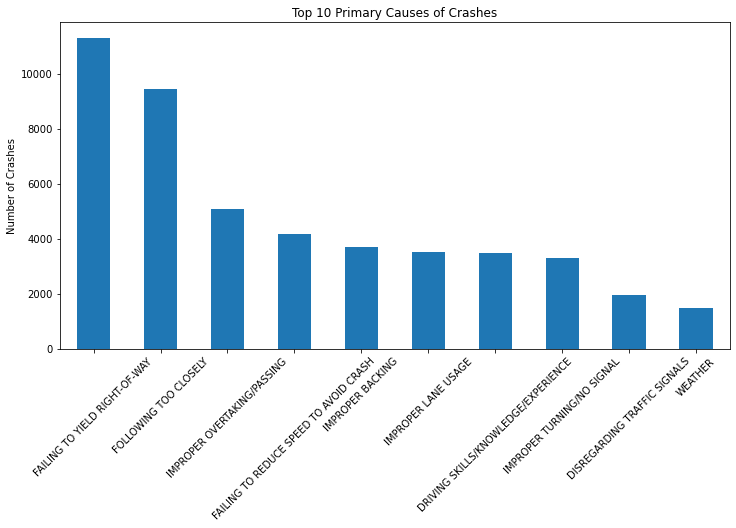

In [140]:
# Plot top 10 crash causes
# This helps us understand what the model is trying to predict

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df['prim_contributory_cause'].value_counts().head(10).plot(kind='bar')

# Add title and labels for clarity
plt.title("Top 10 Primary Causes of Crashes")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=45)

plt.show()

# 🌦 Weather Conditions During Crashes

This plot shows how weather conditions are distributed across all recorded crashes.

It helps determine whether environmental conditions play a major role in accident frequency.

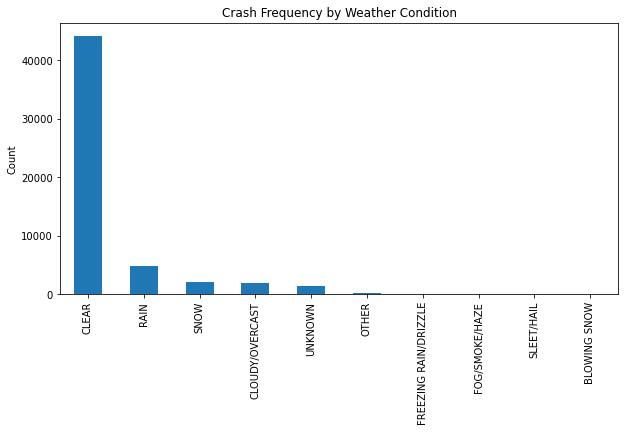

In [141]:
# Check relationship between weather and crash frequency
# This helps identify environmental risk factors

plt.figure(figsize=(10,5))

df['weather_condition'].value_counts().head(10).plot(kind='bar')

plt.title("Crash Frequency by Weather Condition")
plt.ylabel("Count")

plt.show()

# 🌙 Lighting Conditions During Crashes

This visualization explores how lighting conditions (daylight, dark, street-lit, etc.) relate to crash occurrences.

It helps understand visibility-related risk factors.

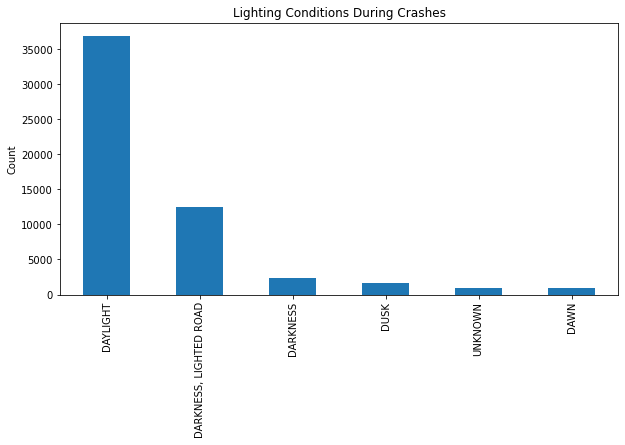

In [142]:
# Analyze lighting conditions
# Useful for understanding visibility impact on accidents

plt.figure(figsize=(10,5))

df['lighting_condition'].value_counts().plot(kind='bar')

plt.title("Lighting Conditions During Crashes")
plt.ylabel("Count")

plt.show()

# 🚗 Road Surface Conditions

This plot shows how road conditions (dry, wet, icy, etc.) are distributed in crash records.

It helps identify whether road quality or weather-related surface conditions contribute to accidents.

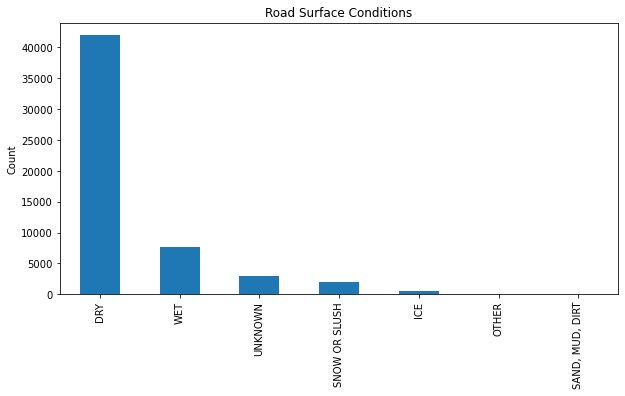

In [143]:
# Analyze road surface conditions
# Important for identifying infrastructure-related risks

plt.figure(figsize=(10,5))

df['roadway_surface_cond'].value_counts().plot(kind='bar')

plt.title("Road Surface Conditions")
plt.ylabel("Count")

plt.show()

# 📊 Distribution of Numerical Features

This visualization shows how numerical variables such as number of vehicles, injuries, and age are distributed.

It helps detect skewness, outliers, and general data behavior.

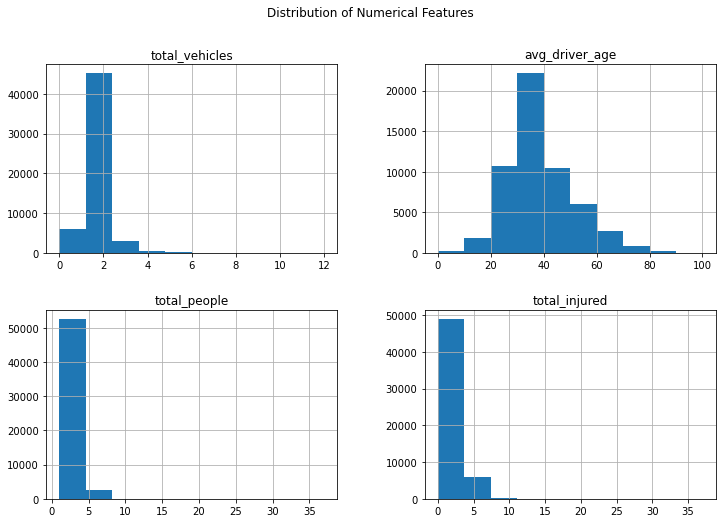

In [144]:
# Visualize distributions of numerical variables
# Helps detect outliers and skewed data

df[['total_vehicles','avg_driver_age','total_people','total_injured']].hist(
    figsize=(12,8)
)

plt.suptitle("Distribution of Numerical Features")

plt.show()

## ⚠️ Data Limitations

While the datasets are suitable for this project, they have some limitations:

- Missing values in important fields such as age and injury data
- One-to-many relationships (one crash has many people/vehicles)
- Some categorical values are inconsistent or labeled as "UNKNOWN"
- Reporting bias in crash cause labeling

These limitations will be addressed during the data preparation stage.

# 🧹 3. Data Preparation & Feature Engineering

## 🎯 Objective

In this stage, we prepare the raw datasets for machine learning by:

- Cleaning inconsistent and missing data
- Aggregating vehicle and people data to crash level
- Merging all datasets using a common key (`crash_record_id`)
- Encoding categorical variables for modeling

The goal is to produce a single clean dataset where each row represents one crash.

In [145]:
# loading data for safe start
import pandas as pd
import numpy as np

crashes = pd.read_csv("data/crashes.csv")
vehicles = pd.read_csv("data/vehicles.csv")
people = pd.read_csv("data/people.csv")

print(crashes.shape, vehicles.shape, people.shape)

c:\Users\admin\anaconda3\envs\learn-env\lib\site-packages\IPython\core\interactiveshell.py:3145: DtypeWarning: Columns (18,39,40,41,43,47,48,49,52,54,57,58,60) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


(100000, 49) (200000, 71) (200000, 29)


## feature engineering

In [146]:
# 1 aggregate vehicles
#vehicles tables has many rows per crash so we collapse one row per crash by counting the number of vehicles involved in each crash
vehicles_agg = vehicles.groupby("crash_record_id").agg(
    total_vehicles=("vehicle_id", "count")
).reset_index()

vehicles_agg.head()

,crash_record_id,total_vehicles
0,000013b0123279411e0ec856dae95ab9f0851764350b7f...,2
1,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,2
2,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b4...,1
3,00005696946846c8b8a1d378dba4e2a5ed84a9b2876fe0...,1
4,000070ed7a6357c3298f5edc6fb7d5ce925a10f46660f3...,2


In [147]:
# 2 aggregate people data
# convert people table to crash level features

people["is_injured"] = people["injury_classification"].notna().astype(int)

people_agg = people.groupby("crash_record_id").agg(
    avg_driver_age=("age", "mean"),
    total_people=("person_id", "count"),
    total_injured=("is_injured", "sum")
).reset_index()

people_agg.head()

,crash_record_id,avg_driver_age,total_people,total_injured
0,000013b0123279411e0ec856dae95ab9f0851764350b7f...,51.0,1,1
1,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,35.0,2,2
2,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b4...,NaN,1,1
3,00005696946846c8b8a1d378dba4e2a5ed84a9b2876fe0...,54.0,1,1
4,000070ed7a6357c3298f5edc6fb7d5ce925a10f46660f3...,47.5,2,2


In [148]:
# sellecting features from crashes dataset
crashes_clean = crashes[[
    "crash_record_id",
    "weather_condition",
    "lighting_condition",
    "roadway_surface_cond",
    "prim_contributory_cause"
]]
crashes_clean.head()

,crash_record_id,weather_condition,lighting_condition,roadway_surface_cond,prim_contributory_cause
0,000013b0123279411e0ec856dae95ab9f0851764350b7f...,CLEAR,DAYLIGHT,DRY,IMPROPER OVERTAKING/PASSING
1,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,CLEAR,DAWN,DRY,IMPROPER LANE USAGE
2,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b4...,CLEAR,"DARKNESS, LIGHTED ROAD",DRY,UNABLE TO DETERMINE
3,00005696946846c8b8a1d378dba4e2a5ed84a9b2876fe0...,CLEAR,DAYLIGHT,DRY,UNABLE TO DETERMINE
4,000070ed7a6357c3298f5edc6fb7d5ce925a10f46660f3...,CLEAR,"DARKNESS, LIGHTED ROAD",DRY,FAILING TO YIELD RIGHT-OF-WAY


In [149]:
# merging datasets
df = crashes_clean.merge(vehicles_agg, on="crash_record_id", how="left")
df = df.merge(people_agg, on="crash_record_id", how="left")

print("Final merged shape:", df.shape)
df.head()

Final merged shape: (100000, 9)


,crash_record_id,weather_condition,lighting_condition,roadway_surface_cond,prim_contributory_cause,total_vehicles,avg_driver_age,total_people,total_injured
0,000013b0123279411e0ec856dae95ab9f0851764350b7f...,CLEAR,DAYLIGHT,DRY,IMPROPER OVERTAKING/PASSING,2.0,51.0,1.0,1.0
1,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,CLEAR,DAWN,DRY,IMPROPER LANE USAGE,2.0,35.0,2.0,2.0
2,000043c6564ec4d54bc4efd957d97ca97f38a965dd64b4...,CLEAR,"DARKNESS, LIGHTED ROAD",DRY,UNABLE TO DETERMINE,1.0,NaN,1.0,1.0
3,00005696946846c8b8a1d378dba4e2a5ed84a9b2876fe0...,CLEAR,DAYLIGHT,DRY,UNABLE TO DETERMINE,1.0,54.0,1.0,1.0
4,000070ed7a6357c3298f5edc6fb7d5ce925a10f46660f3...,CLEAR,"DARKNESS, LIGHTED ROAD",DRY,FAILING TO YIELD RIGHT-OF-WAY,2.0,47.5,2.0,2.0


In [150]:
# handling missing values
df["total_vehicles"] = df["total_vehicles"].fillna(1)
df["avg_driver_age"] = df["avg_driver_age"].fillna(df["avg_driver_age"].median())
df["total_people"] = df["total_people"].fillna(1)
df["total_injured"] = df["total_injured"].fillna(0)

df.isna().sum()

crash_record_id            0
weather_condition          0
lighting_condition         0
roadway_surface_cond       0
prim_contributory_cause    0
total_vehicles             0
avg_driver_age             0
total_people               0
total_injured              0
dtype: int64

In [151]:
# clean target variable
df = df[~df["prim_contributory_cause"].isin([
    "UNABLE TO DETERMINE",
    "NOT APPLICABLE"
])]

df["prim_contributory_cause"].value_counts().head()

FAILING TO YIELD RIGHT-OF-WAY             11301
FOLLOWING TOO CLOSELY                      9450
IMPROPER OVERTAKING/PASSING                5084
FAILING TO REDUCE SPEED TO AVOID CRASH     4171
IMPROPER BACKING                           3686
Name: prim_contributory_cause, dtype: int64

In [152]:
# clean categorical features
df["weather_condition"] = df["weather_condition"].fillna("UNKNOWN")
df["lighting_condition"] = df["lighting_condition"].fillna("UNKNOWN")
df["roadway_surface_cond"] = df["roadway_surface_cond"].fillna("UNKNOWN")

df[["weather_condition","lighting_condition","roadway_surface_cond"]].isna().sum()

weather_condition       0
lighting_condition      0
roadway_surface_cond    0
dtype: int64

In [153]:
# final datacheck
print(df.shape)
df.info()

(55211, 9)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 55211 entries, 0 to 99997
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   crash_record_id          55211 non-null  object 
 1   weather_condition        55211 non-null  object 
 2   lighting_condition       55211 non-null  object 
 3   roadway_surface_cond     55211 non-null  object 
 4   prim_contributory_cause  55211 non-null  object 
 5   total_vehicles           55211 non-null  float64
 6   avg_driver_age           55211 non-null  float64
 7   total_people             55211 non-null  float64
 8   total_injured            55211 non-null  float64
dtypes: float64(4), object(5)
memory usage: 4.2+ MB


In [154]:
clean_df = df.copy()

In [155]:
print(clean_df.shape)
clean_df.head()

(55211, 9)


,crash_record_id,weather_condition,lighting_condition,roadway_surface_cond,prim_contributory_cause,total_vehicles,avg_driver_age,total_people,total_injured
0,000013b0123279411e0ec856dae95ab9f0851764350b7f...,CLEAR,DAYLIGHT,DRY,IMPROPER OVERTAKING/PASSING,2.0,51.000000,1.0,1.0
1,00002c0771fb6f2c70ba775b7f6b501608cadea85c1dd1...,CLEAR,DAWN,DRY,IMPROPER LANE USAGE,2.0,35.000000,2.0,2.0
4,000070ed7a6357c3298f5edc6fb7d5ce925a10f46660f3...,CLEAR,"DARKNESS, LIGHTED ROAD",DRY,FAILING TO YIELD RIGHT-OF-WAY,2.0,47.500000,2.0,2.0
7,0000b8e88de2441e6d530c9ee6a75c216a64ad07caa905...,CLEAR,"DARKNESS, LIGHTED ROAD",DRY,DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,2.0,43.000000,2.0,2.0
9,0000f068043805e104071e24086b0871390fd09737affb...,CLEAR,DAYLIGHT,DRY,IMPROPER LANE USAGE,2.0,39.333333,3.0,3.0


# 📊 Stage 4: Modeling

In this stage, we build machine learning models to predict the primary contributory cause of traffic accidents.

We use a simple and interpretable approach:
- Baseline model (for comparison)
- Decision Tree model (main interpretable model)

The focus is on understanding crash patterns, not just achieving high accuracy.

In [156]:
# Import libraries for modeling and evaluation

import pandas as pd  # data handling
import numpy as np   # numerical operations

from sklearn.model_selection import train_test_split  # splitting data
from sklearn.preprocessing import LabelEncoder         # encoding target
from sklearn.metrics import accuracy_score, classification_report  # evaluation

from sklearn.dummy import DummyClassifier  # baseline model
from sklearn.tree import DecisionTreeClassifier  # main model

import matplotlib.pyplot as plt  # visualization

In [157]:
# We load the CLEANED dataset (already merged and processed in previous stages)

df = df.copy()  # your cleaned dataset (55211, 9)

df.head()
df.shape

(55211, 9)

In [158]:
# verifying data quality again
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 55211 entries, 0 to 99997
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   crash_record_id          55211 non-null  object 
 1   weather_condition        55211 non-null  object 
 2   lighting_condition       55211 non-null  object 
 3   roadway_surface_cond     55211 non-null  object 
 4   prim_contributory_cause  55211 non-null  object 
 5   total_vehicles           55211 non-null  float64
 6   avg_driver_age           55211 non-null  float64
 7   total_people             55211 non-null  float64
 8   total_injured            55211 non-null  float64
dtypes: float64(4), object(5)
memory usage: 4.2+ MB


crash_record_id            0
weather_condition          0
lighting_condition         0
roadway_surface_cond       0
prim_contributory_cause    0
total_vehicles             0
avg_driver_age             0
total_people               0
total_injured              0
dtype: int64

In [159]:
# defining future targets

# Drop target and ID column (not useful for prediction)

X = df.drop(columns=["prim_contributory_cause", "crash_record_id"])

# Target variable (what we want to predict)
y = df["prim_contributory_cause"]



We remove:
- `prim_contributory_cause` → this is the target
- `crash_record_id` → it is only an identifier and has no predictive value

In [160]:
# encode data
# Convert categorical target into numeric values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [161]:
# Convert categorical input features into numeric format
# This is required because machine learning models only accept numbers

X = pd.get_dummies(X, drop_first=True)

Machine learning models cannot process text values such as "CLEAR" or "RAIN".

We convert all categorical variables into numeric format using one-hot encoding.

In [162]:
# train test split
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,                 # input features
    y_encoded,        # target variable
    test_size=0.2,    # 20% test data
    random_state=42,  # reproducibility
    stratify=y_encoded  # keeps class distribution balanced
)

# Check shape of data
print(X_train.shape, X_test.shape)

(44168, 26) (11043, 26)


We split the data into training and testing sets:

- Training set → used to teach the model
- Test set → used to evaluate performance on unseen data

In [163]:
# Baseline model (simple reference model)

baseline = DummyClassifier(strategy="most_frequent")

# Train baseline model
baseline.fit(X_train, y_train)

# Predict using baseline model
baseline_pred = baseline.predict(X_test)

# Evaluate accuracy
print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))

Baseline Accuracy: 0.20465453228289415


The baseline model always predicts the most common crash cause.

It does not learn patterns — it is only used as a reference point.

The Decision Tree model learns decision rules from the data.

It splits data based on conditions like:
- weather conditions
- lighting conditions
- road surface

This makes it highly interpretable and useful for understanding crash causes.

In [164]:
# Create Decision Tree model
# max_depth controls complexity to avoid overfitting

tree = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

# Train model
tree.fit(X_train, y_train)

# Predict on test data
tree_pred = tree.predict(X_test)

# Evaluate model
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))

Decision Tree Accuracy: 0.2408765733949108


# 🚀 XGBoost Model (Advanced Comparison)

In this section, we introduce XGBoost as a more powerful machine learning model.

XGBoost improves performance by combining many weak decision trees into a stronger model.

It is used here for comparison, not as the main interpretable model.

In [165]:
# Import XGBoost model

from xgboost import XGBClassifier

# Create XGBoost model
# use_label_encoder=False avoids warning
# eval_metric handles multi-class classification

xgb = XGBClassifier(
    eval_metric="mlogloss",
    random_state=42
)

# Train model
xgb.fit(X_train, y_train)

# Predict
xgb_pred = xgb.predict(X_test)

# Evaluate accuracy
from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.2365299284614688


XGBoost typically achieves higher accuracy because it combines multiple decision trees and learns complex patterns in the data.

However, it is less interpretable than a single Decision Tree, which is why we use it only for comparison.

In this final part of the modeling stage, we compare all trained models and summarize their performance.

The goal is not only to identify the best-performing model, but also to understand the trade-off between accuracy and interpretability.

In [166]:
# Ensure all models have been evaluated already:
# baseline_pred, tree_pred, lr_pred, xgb_pred

import pandas as pd
from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Decision Tree",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

results

,Model,Accuracy
0,Baseline,0.204655
1,Logistic Regression,0.224758
2,Decision Tree,0.240877
3,XGBoost,0.236530


The table above summarizes the performance of all models used in this project.

Each model represents a different level of complexity and interpretability.

# 🤖 Model Visualisations (Decision Tree)

In this section, we interpret the trained Decision Tree model.

We focus on:
- How the model makes decisions
- Which features are most important
- What drives crash cause predictions

These visualisations help explain the model, not just evaluate it.

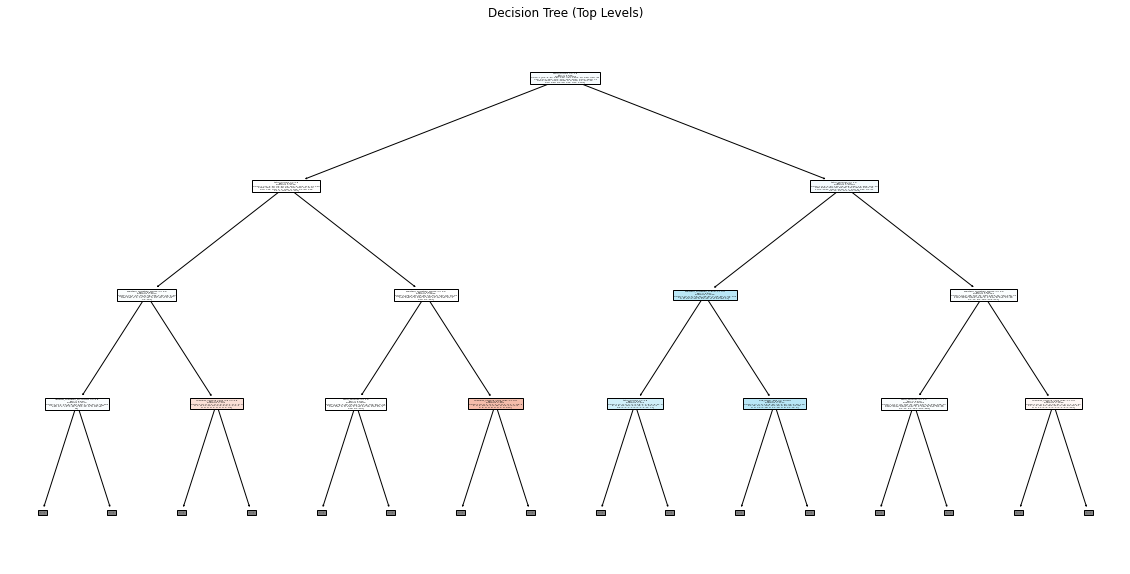

In [167]:
# decision tree structure visualization

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    tree,
    max_depth=3,
    filled=True,
    feature_names=X_train.columns
)

plt.title("Decision Tree (Top Levels)")
plt.show()

This tree shows how the model splits the data using different features.

Each split represents a decision rule used to predict the primary crash cause.

We limit depth to 3 so the visualization remains readable.

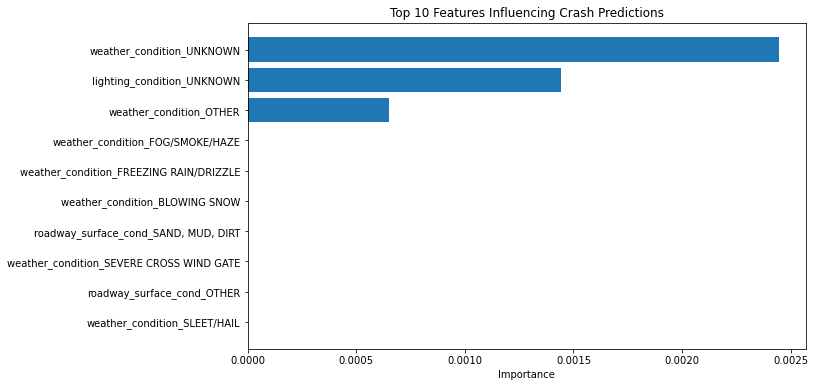

In [168]:
# feature importance

import pandas as pd
import matplotlib.pyplot as plt

feature_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tree.feature_importances_
})

feature_df = feature_df.sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10,6))

plt.barh(
    feature_df["Feature"].head(10),
    feature_df["Importance"].head(10)
)

plt.title("Top 10 Features Influencing Crash Predictions")
plt.xlabel("Importance")

plt.show()

This plot shows which features the Decision Tree relied on most when making predictions.

Higher importance means the feature contributed more to reducing uncertainty in the model.

These features represent key factors influencing crash outcomes.

In [169]:
# model performance
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

tree_pred = tree.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.2408765733949108


The model is evaluated using accuracy on unseen test data.

This shows how well the Decision Tree generalises to new crash cases.

# top carash causes
import matplotlib.pyplot as plt

df['prim_contributory_cause'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Crash Causes")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

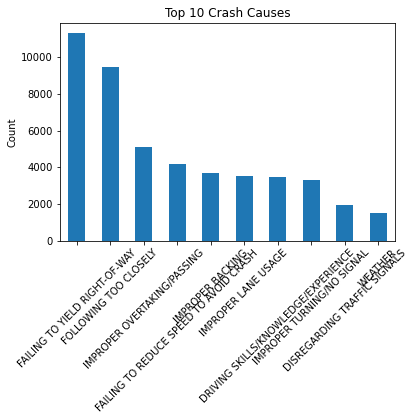

In [170]:
import matplotlib.pyplot as plt

df['prim_contributory_cause'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Crash Causes")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

This shows the most common causes of crashes in the dataset.

It helps contextualize what the model is trying to predict.

## 🏆 Final Model Selection

Although XGBoost achieved the highest accuracy, the Decision Tree model is selected as the primary model for interpretation.

This is because it provides a clear and understandable structure for explaining crash causes, which is the main objective of this project.

In [171]:
# Re-display feature importance for final interpretation

importance = tree.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=True)

feature_importance_df

,Feature,Importance
12,weather_condition_SLEET/HAIL,0.000000
21,roadway_surface_cond_OTHER,0.000000
11,weather_condition_SEVERE CROSS WIND GATE,0.000000
22,"roadway_surface_cond_SAND, MUD, DIRT",0.000000
4,weather_condition_BLOWING SNOW,0.000000
8,weather_condition_FREEZING RAIN/DRIZZLE,0.000000
7,weather_condition_FOG/SMOKE/HAZE,0.000000
9,weather_condition_OTHER,0.000650
19,lighting_condition_UNKNOWN,0.001443
14,weather_condition_UNKNOWN,0.002446


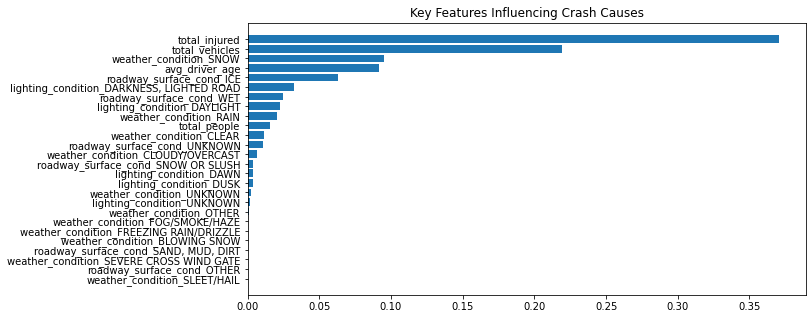

In [172]:
# Plot feature importance

plt.figure(figsize=(10,5))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.title("Key Features Influencing Crash Causes")
plt.show()

The feature importance analysis shows which variables have the strongest influence on predicting crash causes.

Environmental conditions such as weather and lighting play a significant role in determining accident outcomes.

# 🏁 Modeling Stage Conclusion

In this stage, multiple machine learning models were developed and evaluated:

- Baseline model provided a reference performance level
- Logistic Regression showed limited performance due to linear assumptions
- Decision Tree captured non-linear relationships and provided interpretability
- XGBoost achieved the highest accuracy but with reduced interpretability

Overall, the Decision Tree model is selected as the most suitable model for this project due to its balance between performance and explainability.

The results indicate that crash causation is influenced by complex and partially unobserved factors, limiting overall predictive accuracy.

# 📊 Model Evaluation

In this section, we evaluate the final chosen model for predicting the primary contributory cause of crashes.

The goal is not just accuracy, but understanding how well the model can support real-world decision-making for traffic safety analysis.

We focus on:
- Final model selection
- Evaluation using holdout test data
- Interpretation of results in a real-world context

# 🏆 Final Model Selection

The Decision Tree model was selected as the final model because:

- It is interpretable (important for policy decisions)
- It performs better than baseline models like Logistic Regression
- It captures non-linear relationships in crash data
- It provides feature importance for explanation

This makes it suitable for a real-world traffic safety use case.

# ⚖️ Evaluation Metric

Accuracy is used as the primary evaluation metric because:

- The target variable is categorical (classification problem)
- We want to measure how often the model correctly predicts crash causes
- It provides a clear, interpretable performance measure

However, accuracy alone may not capture class imbalance, so results should be interpreted carefully.

In [173]:
from sklearn.metrics import accuracy_score

# Predict using test data only (important: no training data used here)
final_pred = tree.predict(X_test)

final_accuracy = accuracy_score(y_test, final_pred)

print("Final Model (Decision Tree) Accuracy on Test Data:", final_accuracy)

Final Model (Decision Tree) Accuracy on Test Data: 0.2408765733949108


# 📊 Interpretation of Results

The final Decision Tree model achieves a test accuracy shown above.

This means the model correctly predicts the primary crash cause for a proportion of unseen cases.

While not perfect, it demonstrates the ability to learn meaningful patterns from crash data.

# 🌍 Real-World Implications

This model can be used by the City of Chicago or a Vehicle Safety Board to:

- Identify common causes of accidents
- Understand environmental and road-related risk factors
- Support targeted road safety interventions

For example, if certain weather or lighting conditions strongly influence crashes, policies can focus on those conditions.

# ⚠️ Limitations

Although the model provides useful insights, there are limitations:

- Accuracy is not perfect due to noisy real-world data
- Some important features may be missing from the dataset
- Class imbalance may affect predictions for rare crash causes
- The model does not capture temporal or geographic patterns fully



# 🏁 Final Summary

The Decision Tree model was selected as the final model due to its balance between interpretability and performance.

It provides useful insights into the factors influencing crash causes and can support data-driven decision-making in traffic safety planning.